This piece of code performs training of the NN against the PDF data. Prepared PDF data is required to run this code. The labels for data are taken from the names of each dataset, so better be prepared for labelling. In principle, this code can process both calculated PDF data, as well as experimental PDF data. The latter may require additinal processing which is performed by 'preparePDFexp.ipynb'. Calculated data may be prepared from a batch of xyz files by 'preparePDF.ipynb'

In [1]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
import keras
import keras.regularizers
import glob
import os
import itertools
import fnmatch

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score

from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner import RandomSearch, Hyperband
from keras_tuner.engine.hyperparameters import HyperParameters

In [2]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data')

In [3]:
files_calc = glob.glob('*.dat')
files_exp = glob.glob('*processed.gr')

Let's slice a structure set for it to be shorter and more balanced in terms of heavy atom counts

Counts of clusters by their nuclearity: {'1': 0, '2': 13, '3': 12, '4': 50, '5': 10, '6': 19, '7': 8, '8': 5, '9': 6}
Sliced cluster catalogue: ['3_RAQFIA.dat', '4_EGEYOF.dat', '3_Gd3_new_cluster.dat', '4_dy4.dat', '4_MAGFOR.dat', '7_XOSZOW.dat', '6_Nd6O.dat', '4_ATODUK.dat', '4_ATODOE.dat', '2_GETPEB.dat', '3_AZUFUW.dat', '4_Nd4_tetr.dat', '2_DELHIM.dat', '7_OCOSIK.dat', '6_eu6-glaz.dat', '2_NAJKIU01.dat', '6_tb6piv.dat', '2_WABCIM.dat', '7_DOVBUN.dat', '4_IJAQOA.dat', '2_NERWOX.dat', '4_BOQXAH.dat', '2_la2(tfa)6(deta)2.dat', '6_Nd6.dat', '4_QEJWUZ.dat', '8_VIMNUC.dat', '6_SUTROQ.dat', '4_sm4_mono.dat', '5_HOPJAX01.dat', '4_Gd4_opt.dat', '7_BODGOS.dat', '3_Gd3(O)(tfa)7(Htfa)(H2O)n_opt.dat', '4_IMIGAN.dat', '4_Nd4.dat', '8_DAQJEM.dat', '4_tb4.dat', '9_BALLIL.dat', '5_LAVJAV.dat', '4_Eu4.dat', '2_Gd2(tfa)5(iPrOH)2(H2O)4_opt.dat', '4_ga18.dat', '8_UKANEA.dat', '6_CAKBAT.dat', '5_ARULIK.dat', '4_KIFDEI.dat', '6_XIRNIV.dat', '4_GIZVOA.dat', '6_wrong_cpd.dat', '3_HAYNIF.dat', '3_ADUSUO.dat'

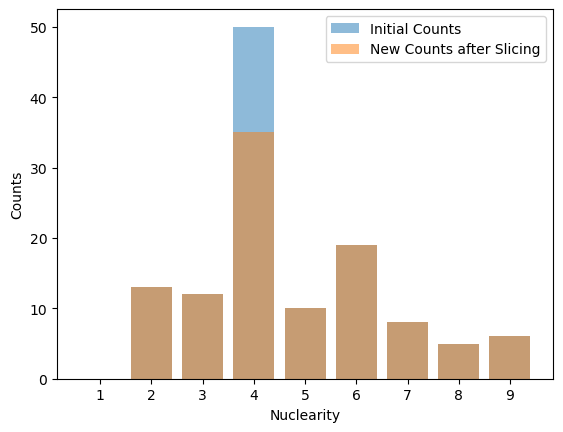

In [4]:
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_filenames(filenames):
    # Count how many filenames start with each digit from 1 to 9
    counts = defaultdict(int)
    for filename in filenames:
        if filename[0].isdigit() and filename[0] != '0':
            counts[filename[0]] += 1
            
    return counts

def create_output_array(filenames, selected_counts):
    # Create the output array based on the selected counts for each digit
    output_array = []
    current_counts = defaultdict(int)
    for filename in filenames:
        digit = filename[0]
        if digit in selected_counts and current_counts[digit] < selected_counts[digit]:
            output_array.append(filename)
            current_counts[digit] += 1
            
    return output_array

files_calc.extend(files_exp)
counts = analyze_filenames(files_calc)
sorted_counts = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts)

selected_counts = {
    '1': 100, # Specify how many filenames starting with '1' you want
    '2': 100, # Specify how many filenames starting with '2' you want
    '3': 100,  # Specify how many filenames starting with '3' you want
    '4': 35,  # Specify how many filenames starting with '3' you want
    '5': 100,  # Specify how many filenames starting with '3' you want
    '6': 100,  # Specify how many filenames starting with '3' you want
    '7': 100,  # Specify how many filenames starting with '3' you want
    '8': 100,  # Specify how many filenames starting with '3' you want
    '9': 100  # Specify how many filenames starting with '3' you want
}

files_calc_sliced = create_output_array(files_calc, selected_counts)
print("Sliced cluster catalogue:", files_calc_sliced)

counts = analyze_filenames(files_calc_sliced)
sorted_counts2 = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts2)

digits = list(sorted_counts.keys())
initial_values = list(sorted_counts.values())
new_values = list(sorted_counts2.values()) # Use sorted counts for the new values

total_elements_in_sliced = len(files_calc_sliced)
print("Total number of elements in the sliced cluster catalogue:", total_elements_in_sliced)

plt.bar(digits, initial_values, alpha=0.5, label='Initial Counts')
plt.bar(digits, new_values, alpha=0.5, label='New Counts after Slicing')
plt.xlabel('Nuclearity')
plt.ylabel('Counts')
plt.legend()
plt.show()


In [5]:
raw_data_points = []

with open('labels.txt', 'w') as labels:
    for f in files_calc_sliced:
        if 'processed' in f:
            # For files containing 'processed' in their names (second type)
            df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, skipfooter=1, engine='python')
        else:
            # For files not containing 'processed' in their names (first type)
            df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=0, engine='python')

        raw_data_points.append(df.values.ravel())
        labels.write(f[0])
        labels.write('\n')

raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv("labels.txt", header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

3


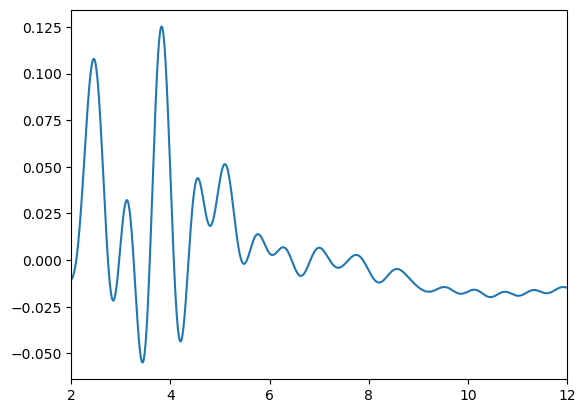

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
# Preprocessing
#scaler = MinMaxScaler()
#scaler = StandardScaler()
#scaler =MaxAbsScaler()
#data_points = scaler.fit_transform(data_points)
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[85,:]))/100+2, data_points[85,:])
print(labels[85])

In [7]:
# Split the data into training, validation and test sets
X_train, X_val, y_train, y_val = train_test_split(data_points, labels, test_size=0.2, random_state=42)
#X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [8]:
# Let's do some hyperparameter tuning

def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [4, 8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [32, 64, 128, 256]),
                     activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout1', 0.1, 0.9, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [8, 16, 32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64, 128]),
                     activation='relu'))
    model.add(Dropout(hp.Float('dropout2', 0.1, 0.9, step=0.1)))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [32, 64, 128, 256]), activation=hp.Choice('activation',['relu', 'softmax']), kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout3', 0.1, 0.9, step=0.1)))
    model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [9]:
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=150,
    factor=3,
    project_name='hyperband'
)

tuner.search(X_train, y_train, epochs=150, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

Trial 254 Complete [00h 00m 05s]
val_accuracy: 0.1818181872367859

Best val_accuracy So Far: 0.8181818127632141
Total elapsed time: 00h 12m 41s
INFO:tensorflow:Oracle triggered exit


In [10]:
tuner.search_space_summary()
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hyperparameters.values)
best_model = tuner.get_best_models(num_models=1)[0]
best_model.save('tuned_sliced_all_2-12.h5')

Search space summary
Default search space size: 10
filters1 (Choice)
{'default': 4, 'conditions': [], 'values': [4, 8, 16, 32], 'ordered': True}
kernel_size1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128, 256], 'ordered': True}
dropout1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.9, 'step': 0.1, 'sampling': 'linear'}
filters2 (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32, 64, 128], 'ordered': True}
kernel_size2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64, 128], 'ordered': True}
dropout2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.9, 'step': 0.1, 'sampling': 'linear'}
dense_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128, 256], 'ordered': True}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'softmax'], 'ordered': False}
dropout3 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.9, 'step':

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_4 (Conv1D)           (None, 969, 16)           528       
                                                                 
 batch_normalization_2 (Batc  (None, 969, 16)          64        
 hNormalization)                                                 
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 484, 16)          0         
 1D)                                                             
                                                                 
 dropout_6 (Dropout)         (None, 484, 16)           0         
                                                                 
 conv1d_5 (Conv1D)           (None, 357, 32)           65568     
                                                                 
 dropout_7 (Dropout)         (None, 357, 32)          

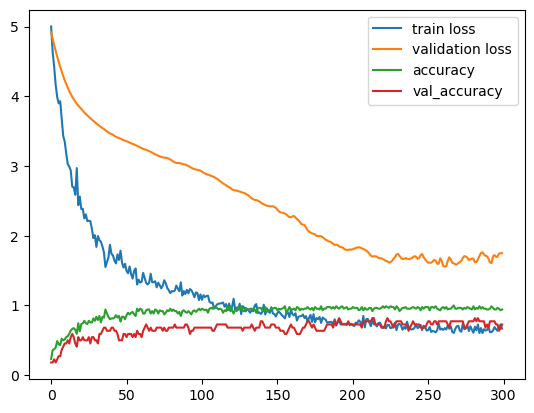

In [15]:
# Retrain the model if needed
num_epochs = 300

model = Sequential()
model.add(Conv1D(filters=16, kernel_size=32, activation='relu', input_shape=(1000, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2)) # 2
model.add(Dropout(0.1))
model.add(Conv1D(filters=32, kernel_size=128, activation='relu'))
model.add(Dropout(0.9))
model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
model.add(Flatten())
model.add(Dense(units=128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))) # 128 0.01
model.add(Dropout(0.5))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))) # 10 0.01

# Compile the model
optimizer = Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

checkpoint = ModelCheckpoint("tuned_sliced_all_2-12_retrain.h5", monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

seqModel = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
# Evaluate the model on the validation set
test_loss, test_acc = model.evaluate(X_val, y_val)
print('Validation accuracy:', test_acc)

print(seqModel.history.keys())
xc         = range(num_epochs)

plt.plot(xc, seqModel.history['loss'], label='train loss')
plt.plot(xc, seqModel.history['val_loss'], label='validation loss')
plt.plot(xc, seqModel.history['accuracy'], label='accuracy')
plt.plot(xc, seqModel.history['val_accuracy'], label='val_accuracy')
plt.legend()

Let's load the model trained on the model clusters and look how is it performing on a real dataset

In [21]:
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/th_clusters/test_th_groups/tuned_sliced_th_calc_2-12_retrain.h5')

In [22]:
load_model.evaluate(X_val, y_val)
y_pred_prob = load_model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_val, y_pred)
recall = recall_score(y_val, y_pred, average=None)
f1 = f1_score(y_val, y_pred, average=None)
precision = precision_score(y_val, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

1/1 [==============================] - 0s 109ms/step
Confusion matrix [[0 0 2 1 0 0 0]
 [0 0 0 0 3 0 0]
 [0 0 0 1 3 0 0]
 [0 0 0 1 2 0 0]
 [0 0 0 0 4 0 1]
 [0 0 0 0 2 1 0]
 [0 0 0 0 0 1 0]]
Recall score: [0.         0.         0.         0.33333333 0.8        0.33333333
 0.        ]
F1 score: [0.         0.         0.         0.33333333 0.42105263 0.4
 0.        ]
Precision score: [0.         0.         0.         0.33333333 0.28571429 0.5
 0.        ]


/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion matrix, without normalization
[[0 0 2 1 0 0 0]
 [0 0 0 0 3 0 0]
 [0 0 0 1 3 0 0]
 [0 0 0 1 2 0 0]
 [0 0 0 0 4 0 1]
 [0 0 0 0 2 1 0]
 [0 0 0 0 0 1 0]]


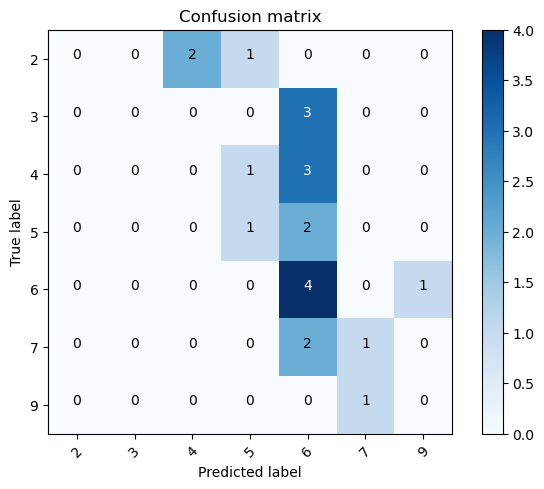

In [23]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_val), title='Confusion matrix', normalize=False)
plt.show()

In [25]:
load_model.evaluate(X_train, y_train)
y_pred_prob = load_model.predict(X_train)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_train, y_pred)
recall = recall_score(y_train, y_pred, average=None)
f1 = f1_score(y_train, y_pred, average=None)
precision = precision_score(y_train, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

3/3 [==============================] - 0s 37ms/step
Confusion matrix [[ 0  2  2  5  1  0  0  0]
 [ 0  0  1  6  2  0  0  0]
 [ 0  0  0  7 19  3  0  2]
 [ 0  0  0  3  3  1  0  0]
 [ 0  0  0  0  8  5  0  1]
 [ 0  0  0  1  4  0  0  0]
 [ 0  0  0  0  3  1  0  1]
 [ 0  0  0  0  2  3  0  0]]
Recall score: [0.         0.         0.         0.42857143 0.57142857 0.
 0.         0.        ]
F1 score: [0.         0.         0.         0.20689655 0.28571429 0.
 0.         0.        ]
Precision score: [0.         0.         0.         0.13636364 0.19047619 0.
 0.         0.        ]


/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
